# Machine Learning — SNP analiza (100 SNP-ova)

**Dataset:** `penncath_preprocessed.csv` — 926 uzoraka, 100 SNP-ova, 1:1 balans  
**Modeli:** Logistic Regression, Random Forest, SVM, XGBoost, MLP, Naive Bayes 

## Import modula

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
COLORS = {
    'healthy':   '#2ec4b6',
    'disease':   '#e63946',
    'primary':   '#4e9af1',
    'secondary': '#7b2d8b'
}
np.random.seed(42)

## 1. Učitavanje dataseta

In [2]:
dataset  = pd.read_csv('../data/penncath_preprocessed.csv')
snp_cols = [col for col in dataset.columns if col != 'target']

print('Shape:',     dataset.shape)
print('Target:\n',  dataset['target'].value_counts())

X = dataset[snp_cols]
y = dataset['target']

Shape: (926, 101)
Target:
 target
0    463
1    463
Name: count, dtype: int64


## 2. Chi-square test

In [3]:
chi2_results = []
for col in snp_cols:
    contingency = pd.crosstab(dataset[col], y)
    chi2, p, _, _ = chi2_contingency(contingency)
    chi2_results.append({'SNP': col, 'chi2': chi2, 'p_value': p})

chi2_df    = pd.DataFrame(chi2_results).sort_values('p_value')
significant = chi2_df[chi2_df['p_value'] < 0.05]

print('Ukupno SNP-ova:    ', len(snp_cols))
print('Značajni (p<0.05): ', len(significant))
print('\nTop 10 SNP-ova:')
print(chi2_df.head(10)[['SNP','chi2','p_value']].round(4).to_string(index=False))

Ukupno SNP-ova:     100
Značajni (p<0.05):  100

Top 10 SNP-ova:
         SNP    chi2  p_value
rs10241452_T 22.7355   0.0000
 rs2841390_C 21.3428   0.0000
 rs9513199_T 20.1746   0.0000
 rs3887998_T 19.8345   0.0000
rs10182136_C 19.6680   0.0001
 rs6904469_A 19.5475   0.0001
 rs2085261_G 19.3717   0.0001
 rs4716185_C 19.3412   0.0001
  rs369427_C 19.3122   0.0001
rs11620144_T 19.2735   0.0001


## 3. Train/Test split i Scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)       

Train: 740 | Test: 186


## 4. Logistic Regression

In [5]:
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_sc, y_train)
print('Best LR params:', lr_grid.best_params_)

lr_best   = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_sc)
y_prob_lr = lr_best.predict_proba(X_test_sc)[:, 1]

tr = accuracy_score(y_train, lr_best.predict(X_train_sc))
te = accuracy_score(y_test,  y_pred_lr)
print(f'Train: {tr:.4f} | Test: {te:.4f} | Gap: {tr-te:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best LR params: {'C': 0.01}
Train: 0.8486 | Test: 0.8065 | Gap: 0.0422


## 5. Random Forest

In [6]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [200, 300],
        'max_depth':         [3, 4],
        'min_samples_split': [20, 30],
        'min_samples_leaf':  [10, 15],
        'max_features':      ['sqrt'],
        'class_weight':      ['balanced']
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)

rf_best   = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

tr = accuracy_score(y_train, rf_best.predict(X_train))
te = accuracy_score(y_test,  y_pred_rf)
print(f'Train: {tr:.4f} | Test: {te:.4f} | Gap: {tr-te:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best RF params: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 300}
Train: 0.8662 | Test: 0.7473 | Gap: 0.1189


## 6. SVM

In [7]:
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    {
        'C':      [0.1, 1, 10, 50, 100, 200],
        'gamma':  ['scale', 0.1, 0.01, 0.001, 0.0001],
        'kernel': ['rbf']
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
svm_grid.fit(X_train_sc, y_train)
print('Best SVM params:', svm_grid.best_params_)

svm_best   = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_sc)
y_prob_svm = svm_best.predict_proba(X_test_sc)[:, 1]

tr = accuracy_score(y_train, svm_best.predict(X_train_sc))
te = accuracy_score(y_test,  y_pred_svm)
print(f'Train: {tr:.4f} | Test: {te:.4f} | Gap: {tr-te:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best SVM params: {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
Train: 0.8405 | Test: 0.7957 | Gap: 0.0448


## 7. Gradient Boosting

In [8]:
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01],
    'max_depth': [2],
    'min_samples_leaf': [10, 20, 30]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Najbolji parametri: {gb_grid.best_params_}")
print(f"Najbolji CV ROC-AUC: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test)
y_prob_gb = gb_best.predict_proba(X_test)[:, 1]

tr = accuracy_score(y_train, gb_best.predict(X_train))
te = accuracy_score(y_test,  y_pred_gb)
print(f'Train: {tr:.4f} | Test: {te:.4f} | Gap: {tr-te:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Najbolji parametri: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 20, 'n_estimators': 100}
Najbolji CV ROC-AUC: 0.6366
Train: 0.8068 | Test: 0.6022 | Gap: 0.2046


## 10. Tabela rezultata

In [9]:
models = {
    'Logistic Regression': (y_pred_lr,  y_prob_lr),
    'Random Forest':       (y_pred_rf,  y_prob_rf),
    'SVM':                 (y_pred_svm, y_prob_svm),
    'XGBoost':             (y_pred_gb, y_prob_gb),
}

rows = []
for name, (y_pred, y_prob) in models.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test,  y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test,    y_pred),
        'F1-score':  f1_score(y_test,        y_pred),
        'ROC-AUC':   roc_auc_score(y_test,   y_prob),
    })

results = pd.DataFrame(rows)
print(results.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.8065     0.7879  0.8387    0.8125   0.8796
      Random Forest    0.7473     0.7396  0.7634    0.7513   0.8051
                SVM    0.7957     0.7835  0.8172    0.8000   0.8750
            XGBoost    0.6022     0.6044  0.5914    0.5978   0.6687


## 11. Cross-validation ROC-AUC

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, chi2

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lr_best)
    ]),
    
    'Random Forest': Pipeline([
        ('model', rf_best)
    ]),
    
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm_best)
    ]),
    
    'XGBoost': Pipeline([
        ('model', gb_best)
    ])
}

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    
    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-score': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

cv_df = pd.DataFrame(cv_results)
print("\nCross-validation results:")
print(cv_df.round(4).to_string(index=False))


Cross-validation results:
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.8100     0.8255  0.7863    0.8050   0.8853
      Random Forest    0.7225     0.7273  0.7126    0.7189   0.7888
                SVM    0.7970     0.8160  0.7667    0.7904   0.8812
            XGBoost    0.5810     0.5826  0.5787    0.5794   0.6067


## 12. ROC krive

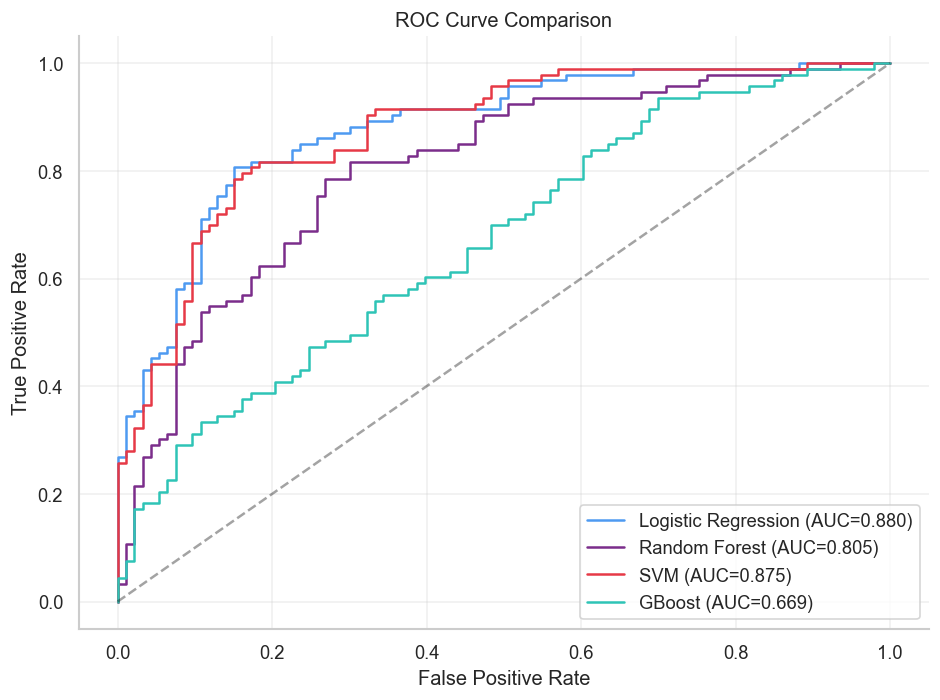

In [11]:
plt.figure(figsize=(8, 6))
plot_models = [
    ('Logistic Regression', y_prob_lr,  COLORS['primary']),
    ('Random Forest',       y_prob_rf,  COLORS['secondary']),
    ('SVM',                 y_prob_svm, COLORS['disease']),
    ('GBoost',             y_prob_gb, COLORS['healthy']),
]
for name, y_prob, color in plot_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../plots/ml_roc.png')
plt.show()

## 13. Confusion matrice

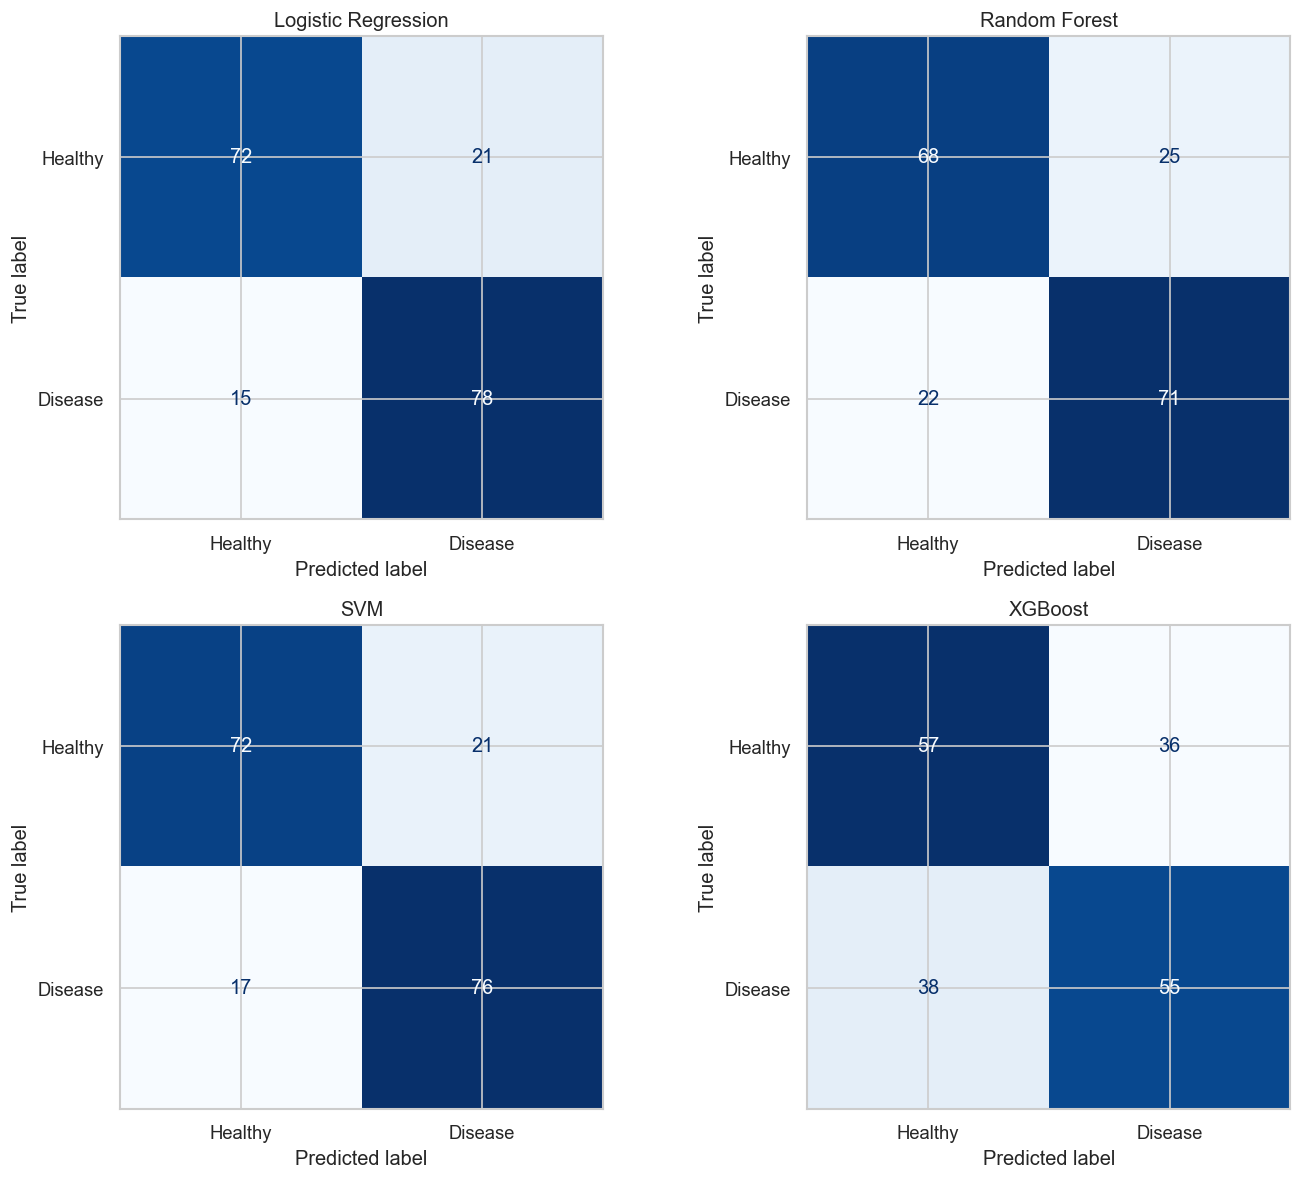

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../plots/ml_confusion.png')
plt.show()

## 14. Feature importance (RF)

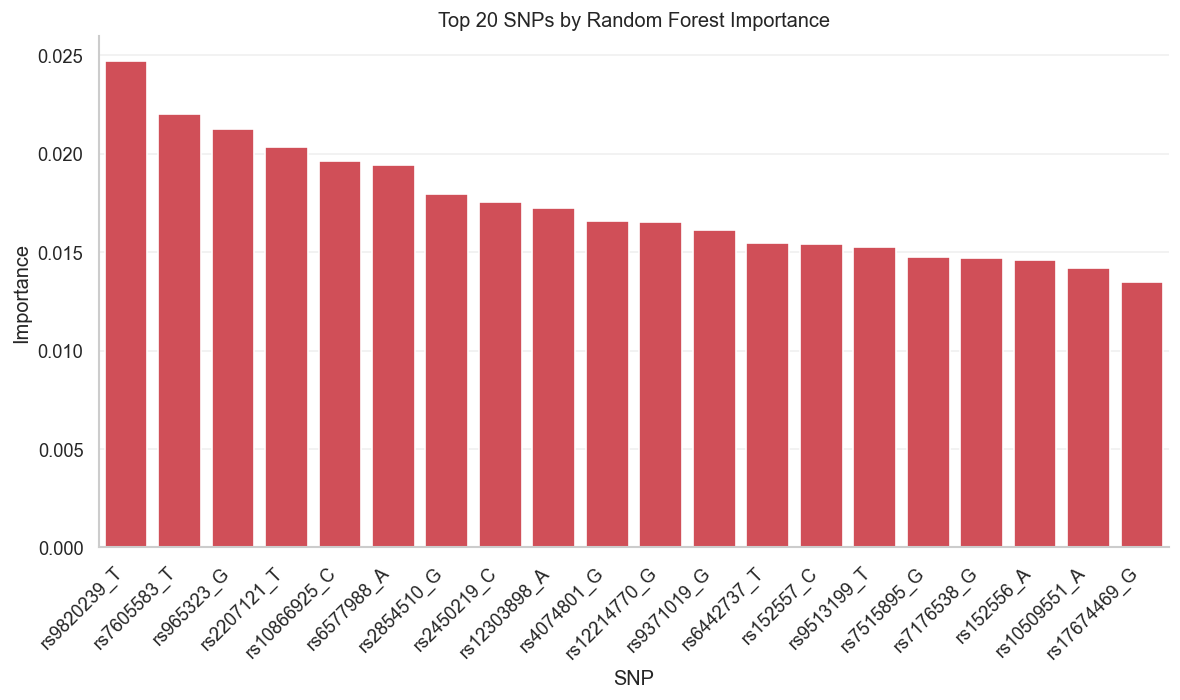

Top 10 SNPs by RF importance:
rs9820239_T     0.0247
rs7605583_T     0.0220
rs965323_G      0.0212
rs2207121_T     0.0203
rs10866925_C    0.0196
rs6577988_A     0.0194
rs2854510_G     0.0180
rs2450219_C     0.0175
rs12303898_A    0.0172
rs4074801_G     0.0166
dtype: float64


In [13]:
importances = pd.Series(
    rf_best.feature_importances_, index=snp_cols
).sort_values(ascending=False)
top20 = importances.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top20.index, y=top20.values, color=COLORS['disease'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 SNPs by Random Forest Importance')
plt.xlabel('SNP')
plt.ylabel('Importance')
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../plots/ml_feature_importance.png')
plt.show()

print('Top 10 SNPs by RF importance:')
print(top20.head(10).round(4))

## 15. Overlap analiza

Chi2 ∩ LR (glavni rezultat):    {'rs2207121', 'rs1508966', 'rs6744132'}
Chi2 ∩ LR ∩ RF:                 {'rs2207121'}
Chi2 ∩ LR ∩ GB:                {'rs2207121'}


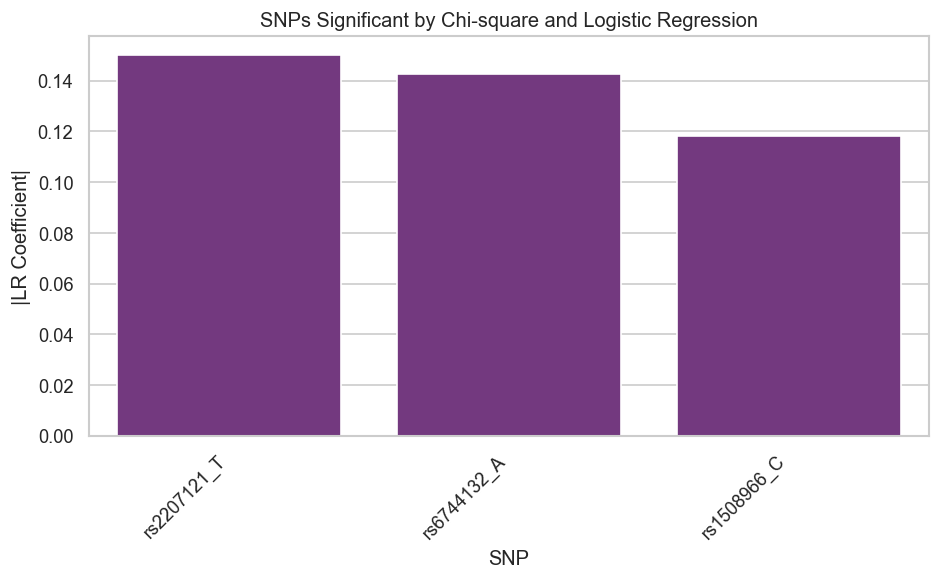

In [14]:
top20_chi2_set = set(
    chi2_df.head(20)['SNP'].str.replace(r'_[A-Z]$', '', regex=True)
)
lr_coefs = pd.Series(
    np.abs(lr_best.coef_[0]), index=snp_cols
).sort_values(ascending=False)


top20_lr_set  = set([c.split('_')[0] for c in lr_coefs.head(20).index])
top20_rf_set  = set([c.split('_')[0] for c in top20.index])
gb_imp       = pd.Series(gb_best.feature_importances_, index=snp_cols).sort_values(ascending=False)
top20_gb_set = set([c.split('_')[0] for c in gb_imp.head(20).index])

overlap_chi2_lr     = top20_chi2_set & top20_lr_set
overlap_chi2_lr_rf  = top20_chi2_set & top20_lr_set & top20_rf_set
overlap_chi2_lr_gb = top20_chi2_set & top20_lr_set & top20_gb_set

print('Chi2 ∩ LR (glavni rezultat):   ', overlap_chi2_lr)
print('Chi2 ∩ LR ∩ RF:                ', overlap_chi2_lr_rf)
print('Chi2 ∩ LR ∩ GB:               ', overlap_chi2_lr_gb)

overlap_snps = [c for c in lr_coefs.index if c.split('_')[0] in overlap_chi2_lr]
overlap_vals = lr_coefs[overlap_snps]

if len(overlap_snps) > 0:
    plt.figure(figsize=(8, 5))
    sns.barplot(x=overlap_vals.index, y=overlap_vals.values, color=COLORS['secondary'])
    plt.xticks(rotation=45, ha='right')
    plt.title('SNPs Significant by Chi-square and Logistic Regression')
    plt.xlabel('SNP')
    plt.ylabel('|LR Coefficient|')
    plt.tight_layout()
    plt.savefig('../plots/ml_overlap_snps.png')
    plt.show()

In [15]:
from itertools import combinations

# --- Chi2 ---
top20_chi2_set = set(
    chi2_df.head(20)['SNP'].str.replace(r'_[A-Z]$', '', regex=True)
)

# --- Logistic Regression ---
lr_coefs = pd.Series(
    np.abs(lr_best.coef_[0]), index=snp_cols
).sort_values(ascending=False)
top20_lr_set = set([c.split('_')[0] for c in lr_coefs.head(20).index])

# --- Random Forest ---
top20_rf_set = set([c.split('_')[0] for c in top20.index])

# --- Gradient Boosting ---
gb_imp = pd.Series(
    gb_best.feature_importances_, index=snp_cols
).sort_values(ascending=False)
top20_gb_set = set([c.split('_')[0] for c in gb_imp.head(20).index])

# --- SVI MODELI U DICTIONARY ---
model_sets = {
    'Chi2': top20_chi2_set,
    'LR': top20_lr_set,
    'RF': top20_rf_set,
    'GB': top20_gb_set
}

# --- PRESJECI ZA 2, 3, 4, 5 MODELA ---
print("\n=== OVERLAP ANALIZA SNP-OVA ===\n")

for r in range(2, 6): 
    print(f"\n--- Presjeci za {r} modela ---")
    
    for combo in combinations(model_sets.keys(), r):
        sets = [model_sets[name] for name in combo if len(model_sets[name]) > 0]
        
        if len(sets) < r:
            continue  
        
        overlap = set.intersection(*sets)
        
        print(f"{' ∩ '.join(combo):<30}: {len(overlap)} SNP-ova -> {overlap}")



main_overlap = top20_chi2_set & top20_lr_set & top20_rf_set
print("\nGlavni presjek (Chi2 ∩ LR ∩ RF):", main_overlap)


=== OVERLAP ANALIZA SNP-OVA ===


--- Presjeci za 2 modela ---
Chi2 ∩ LR                     : 3 SNP-ova -> {'rs2207121', 'rs1508966', 'rs6744132'}
Chi2 ∩ RF                     : 3 SNP-ova -> {'rs2207121', 'rs9371019', 'rs9513199'}
Chi2 ∩ GB                     : 3 SNP-ova -> {'rs2207121', 'rs9371019', 'rs319107'}
LR ∩ RF                       : 11 SNP-ova -> {'rs2207121', 'rs17674469', 'rs12303898', 'rs965323', 'rs6442737', 'rs10866925', 'rs7605583', 'rs2854510', 'rs7176538', 'rs6577988', 'rs9820239'}
LR ∩ GB                       : 11 SNP-ova -> {'rs2207121', 'rs17674469', 'rs965323', 'rs6442737', 'rs10866925', 'rs7605583', 'rs2854510', 'rs17005517', 'rs7176538', 'rs12436661', 'rs9820239'}
RF ∩ GB                       : 13 SNP-ova -> {'rs2207121', 'rs152556', 'rs17674469', 'rs965323', 'rs6442737', 'rs7515895', 'rs12214770', 'rs10866925', 'rs7605583', 'rs2854510', 'rs7176538', 'rs9371019', 'rs9820239'}

--- Presjeci za 3 modela ---
Chi2 ∩ LR ∩ RF                : 1 SNP-ova -> {'rs2